# Classification- Imbalanced Dataset



## Business Problem

For this example, we are trying to predict if it will rain tomorrow based on weather data from Australia. This could be something that would be useful for a weather station or a website to project.

### Import Libraries

In [6]:

import numpy as np
import pandas as pd


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# Load in the data

In [9]:
df = pd.read_csv("/content/weatherAUS (1).csv")


# Brief exploratory data analysis

In [10]:
df.shape

(142193, 24)

In [11]:
# Display the first few rows of the dataset
print(df.head())


         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   
3          NE           24.0         SE  ...        16.0       1017.6   
4           W           41.0        ENE  ...        33.0       1010.8   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RISK_MM  \
0       1007.1       8

In [12]:
# Display basic information about the dataset
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [13]:
# Display summary statistics for numerical columns
print(df.describe())


             MinTemp        MaxTemp       Rainfall   Evaporation  \
count  141556.000000  141871.000000  140787.000000  81350.000000   
mean       12.186400      23.226784       2.349974      5.469824   
std         6.403283       7.117618       8.465173      4.188537   
min        -8.500000      -4.800000       0.000000      0.000000   
25%         7.600000      17.900000       0.000000      2.600000   
50%        12.000000      22.600000       0.000000      4.800000   
75%        16.800000      28.200000       0.800000      7.400000   
max        33.900000      48.100000     371.000000    145.000000   

           Sunshine  WindGustSpeed   WindSpeed9am   WindSpeed3pm  \
count  74377.000000  132923.000000  140845.000000  139563.000000   
mean       7.624853      39.984292      14.001988      18.637576   
std        3.781525      13.588801       8.893337       8.803345   
min        0.000000       6.000000       0.000000       0.000000   
25%        4.900000      31.000000       7.0000

In [14]:
# Check for missing values
print(df.isna().sum())

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64


In [15]:
# create months column
# figure out location data
# what to do with imputed data
# scale data
#remove outliers

## Naive Bayes
    # Outlier removal
    # Encoding
## SVM & Logistic regression Logistic Regression
    # Remove Outliers
    # Remove missing values
    # Scaling
    # dummy variables
## Trees (Decision, RF, XGBoost, GB Tree)
## KNN
    # Feature scaling
    # Imputation
    # dummy variables
## ANN
    # scaling
    # get dummies

# Data Cleaning
1) Drop Null Values in y variable
2) Create a category for Month

In [16]:
#Data Cleaning
df = df.dropna(subset=['RainTomorrow'])
df['month'] = df.Date.apply(lambda x: pd.to_datetime(x).month).astype('category')

# Create model baseline

The dataset is slightly imbalanced. We see that if we project it not to rain every time, our model will be right around 78% of the time. We want our model to perform at least to perform better than this 78% threshold.

In [17]:
df['RainTomorrow'].value_counts()/ df.shape[0]

,count
RainTomorrow,
No,0.775819
Yes,0.224181


# Additional Data Preprocessing
1) Remove outliers
2) Create train test split
3) Create columns for continuous and categorical varaiables

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
import scipy
#adjust for X & Y

def z_score_removal(X,y, columns, z_score):
    df = pd.concat([X, y], axis=1)
    col_df = df[columns]
    z_scores = scipy.stats.zscore(col_df).abs()
    outliers = (z_scores.max(axis=1) > z_score)
    df_out = df[~outliers]
    X_cleaned = df_out[X.columns]
    y_cleaned = df_out.drop(X.columns, axis =1)
    return X_cleaned, y_cleaned


In [19]:
#train test split
from sklearn.model_selection import train_test_split
X = df.drop(['RainTomorrow', 'Date'], axis=1)
y = df.loc[:,'RainTomorrow'].map({'Yes': 1, 'No': 0}).astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [20]:
# Identify continuous and categorical columns
continuous_columns = [col for col in X_train.columns if X_train[col].dtype == 'float64' or X_train[col].dtype == 'int64']
categorical_columns = [col for col in X_train.columns if X_train[col].dtype == 'object']

In [21]:
# pipeline for Naive Bayes - We need to impute continuous columns and encode categorical variables.
nb_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), continuous_columns),
    ('cat', Pipeline([
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_columns)
],remainder = 'passthrough', verbose_feature_names_out= False).set_output(transform='pandas')


# Fit and transform the data
data_transformed = nb_preprocessor.fit_transform(X_train)
nb_X_train, nb_y_train = z_score_removal(data_transformed, y_train, continuous_columns, 3)

In [22]:
# pipeline for SVM & Logistic regression classifiers
lr_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), continuous_columns),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_columns)
],remainder = 'passthrough', verbose_feature_names_out= False).set_output(transform='pandas')

lr_transformed = lr_preprocessor.fit_transform(X_train)
lr_X_train, lr_y_train = z_score_removal(lr_transformed, y_train, continuous_columns, 3)

## Hyperparameter Tuning - Logistic Regression

Logistic Regression is a linear model for classification that uses the logistic function to model the probability of a binary outcome. It's a simple yet powerful technique for solving binary and multi-class classification problems. In scikit-learn, the `LogisticRegression` class provides an implementation of logistic regression.

Relevant Parameters:
- **penalty**: The type of regularization applied to the model. Options include 'l1', 'l2', 'elasticnet', and 'none'. Regularization is used to control the trade-off between fitting the data and keeping the weights small, which helps prevent overfitting.
- **C**: Inverse of regularization strength (i.e., 1/lambda). Smaller values specify stronger regularization. It's used to control the amount of regularization applied to the model, which can impact the model's ability to generalize to unseen data.
- **fit_intercept**: Whether to include an intercept term in the model. If false, the data is assumed to be already centered. Including an intercept can improve the fit of the model, especially if the data is not centered.
- **solver**: The algorithm used for optimization. Choices are 'newton-cg', 'lbfgs', 'liblinear', 'sag', and 'saga'. Each solver has its own benefits and drawbacks, so it's essential to choose the one that best suits your problem and dataset.
- **max_iter**: Maximum number of iterations for the solver to converge. Increasing this value allows the model more time to converge but may increase the computation time.
- **multi_class**: Strategy for multi-class problems. Options are 'auto', 'ovr' (one-vs-rest), and 'multinomial'. 'auto' will choose the best strategy based on the data and solver. For multi-class problems, the choice of strategy can impact the classification performance.

By tuning these parameters, you can find the best combination for your specific problem and achieve a better balance between model complexity and generalization performance.

In [23]:
#Logistic Regression & SVM Code

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV

# Logistic Regression with default parameters
lr_model = LogisticRegression()
lr_scores = cross_val_score(lr_model, lr_X_train, lr_y_train, cv=5, scoring='accuracy')
print(lr_scores)
"""
# Parameter grid for GridSearchCV
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.1, 1, 10],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 500, 1000]
}

grid_search_lr = GridSearchCV(lr_model, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_search_lr.fit(lr_X_train, lr_y_train)
test_score_lr = grid_search_lr.best_estimator_.score(lr_X_train, lr_y_train)

print(f"Best penalty value: {grid_search_lr.best_params_['penalty']}")
print(f"Best C value: {grid_search_lr.best_params_['C']}")
print(f"Best solver value: {grid_search_lr.best_params_['solver']}")
print(f"Best max_iter value: {grid_search_lr.best_params_['max_iter']}")
print(f"Best accuracy: {grid_search_lr.best_score_}")
"""

[0.99721575 0.99726638 0.99822821 0.99726638 0.99751936]


'\n# Parameter grid for GridSearchCV\nparam_grid = {\n    \'penalty\': [\'l1\', \'l2\', \'elasticnet\', \'none\'],\n    \'C\': [0.1, 1, 10],\n    \'solver\': [\'newton-cg\', \'lbfgs\', \'liblinear\', \'sag\', \'saga\'],\n    \'max_iter\': [100, 500, 1000]\n}\n\ngrid_search_lr = GridSearchCV(lr_model, param_grid, scoring=\'accuracy\', cv=5, n_jobs=-1, verbose=1)\ngrid_search_lr.fit(lr_X_train, lr_y_train)\ntest_score_lr = grid_search_lr.best_estimator_.score(lr_X_train, lr_y_train)\n\nprint(f"Best penalty value: {grid_search_lr.best_params_[\'penalty\']}")\nprint(f"Best C value: {grid_search_lr.best_params_[\'C\']}")\nprint(f"Best solver value: {grid_search_lr.best_params_[\'solver\']}")\nprint(f"Best max_iter value: {grid_search_lr.best_params_[\'max_iter\']}")\nprint(f"Best accuracy: {grid_search_lr.best_score_}")\n'

In [25]:
# pipeline for Trees (Decision, RF, XGBoost, GB Tree) - Reuse nb without outlier removval
tree_X_train = nb_preprocessor.fit_transform(X_train)


## Hyperparameter Tuning - Decision Tree

Decision Trees are a popular machine learning algorithm used for both regression and classification tasks. They are easy to interpret and can naturally handle a mixture of continuous and categorical variables.

Relevant Parameters:
- **criterion**: The function to measure the quality of a split. Supported criteria for regression are 'mse' (mean squared error) and 'friedman_mse' (improvement in mean squared error). For classification, supported criteria are 'gini' and 'entropy'.
- **splitter**: The strategy used to choose the split at each node. Supported strategies are 'best' to choose the best split and 'random' to choose the best random split.
- **max_depth**: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. Controlling the depth can help prevent overfitting.
- **min_samples_split**: The minimum number of samples required to split an internal node. A larger value prevents the tree from growing too deep, thus preventing overfitting.
- **min_samples_leaf**: The minimum number of samples required to be at a leaf node. A larger value prevents the tree from growing too deep, thus preventing overfitting.
- **min_weight_fraction_leaf**: The minimum weighted fraction of the sum total of weights required to be at a leaf node. Samples have equal weight when sample_weight is not provided.
- **max_features**: The number of features to consider when looking for the best split. If None, then max_features=n_features.
- **max_leaf_nodes**: Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None, then unlimited number of leaf nodes.
- **min_impurity_decrease**: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
- **min_impurity_split**: Threshold for early stopping in tree growth. A node will split if its impurity is above the threshold, otherwise it is a leaf.

By tuning these parameters, you can find the best combination for your specific problem and achieve a better balance between model complexity and generalization performance.


In [26]:
# Trees (Decision, RF, XGBoost, GB Tree) Code
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# Decision Tree with default parameters
dt_model = DecisionTreeClassifier()
dt_scores = cross_val_score(dt_model, tree_X_train, y_train, cv=5, scoring='accuracy')
print(dt_scores)

"""
# Expanded parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 30, 40, 50],
    'min_impurity_decrease': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'class_weight': [None, 'balanced']
}

grid_search_dt = GridSearchCV(dt_model, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(tree_X_train, y_train)
test_score_dt = grid_search_dt.best_estimator_.score(tree_X_train, y_train)

print("Best hyperparameters found:")
for key, value in grid_search_dt.best_params_.items():
    print(f"{key}: {value}")

print(f"Best accuracy: {grid_search_dt.best_score_}")

"""

[1. 1. 1. 1. 1.]


'\n# Expanded parameter grid for GridSearchCV\nparam_grid = {\n    \'criterion\': [\'gini\', \'entropy\'],\n    \'splitter\': [\'best\', \'random\'],\n    \'max_depth\': [None, 5, 10, 15, 20, 25, 30, 35, 40],\n    \'min_samples_split\': [2, 5, 10, 15, 20],\n    \'min_samples_leaf\': [1, 2, 4, 6, 8, 10],\n    \'min_weight_fraction_leaf\': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],\n    \'max_features\': [None, \'sqrt\', \'log2\'],\n    \'max_leaf_nodes\': [None, 10, 20, 30, 40, 50],\n    \'min_impurity_decrease\': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],\n    \'class_weight\': [None, \'balanced\']\n}\n\ngrid_search_dt = GridSearchCV(dt_model, param_grid, scoring=\'accuracy\', cv=5, n_jobs=-1, verbose=1)\ngrid_search_dt.fit(tree_X_train, y_train)\ntest_score_dt = grid_search_dt.best_estimator_.score(tree_X_train, y_train)\n\nprint("Best hyperparameters found:")\nfor key, value in grid_search_dt.best_params_.items():\n    print(f"{key}: {value}")\n\nprint(f"Best accuracy: {grid_search_dt.best_score_}")\n\n'

## Hyperparameter Tuning - Random Forest

Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time and outputs the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is highly flexible and can handle a wide variety of tasks.

Relevant Parameters:
- **n_estimators**: The number of trees in the forest. Increasing the number of trees can improve the model's performance, but may also increase the computation time.
- **criterion**: The function to measure the quality of a split. Supported criteria for regression are 'mse' (mean squared error) and 'mae' (mean absolute error). For classification, supported criteria are 'gini' and 'entropy'.
- **max_depth**: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. Controlling the depth can help prevent overfitting.
- **min_samples_split**: The minimum number of samples required to split an internal node. A larger value prevents the tree from growing too deep, thus preventing overfitting.
- **min_samples_leaf**: The minimum number of samples required to be at a leaf node. A larger value prevents the tree from growing too deep, thus preventing overfitting.
- **min_weight_fraction_leaf**: The minimum weighted fraction of the sum total of weights required to be at a leaf node. Samples have equal weight when sample_weight is not provided.
- **max_features**: The number of features to consider when looking for the best split. If None, then max_features=n_features. It can also be a float, int, or string ('auto', 'sqrt', or 'log2').
- **max_leaf_nodes**: Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None, then unlimited number of leaf nodes.
- **min_impurity_decrease**: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
- **bootstrap**: Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
- **oob_score**: Whether to use out-of-bag samples to estimate the generalization accuracy.

By tuning these parameters, you can find the best combination for your specific problem and achieve a better balance between model complexity and generalization performance.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# Random Forest with default parameters
rf_model = RandomForestClassifier()
rf_scores = cross_val_score(rf_model, tree_X_train, y_train, cv=5, scoring='accuracy')
print(rf_scores)

"""
# Expanded parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 30, 40, 50],
    'min_impurity_decrease': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
    'warm_start': [False, True],
    'oob_score': [False, True]
}

grid_search_rf = GridSearchCV(rf_model, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_search_rf.fit(tree_X_train, y_train)
test_score_rf = grid_search_rf.best_estimator_.score(tree_X_train, y_train)

print("Best hyperparameters found:")
for key, value in grid_search_rf.best_params_.items():
    print(f"{key}: {value}")

print(f"Best accuracy: {grid_search_rf.best_score_}")
"""

[0.99985935 0.99995312 1.         0.99995312 0.99995311]


'\n# Expanded parameter grid for GridSearchCV\nparam_grid = {\n    \'n_estimators\': [10, 50, 100, 200, 300],\n    \'criterion\': [\'gini\', \'entropy\'],\n    \'max_depth\': [None, 5, 10, 15, 20, 25, 30, 35, 40],\n    \'min_samples_split\': [2, 5, 10, 15, 20],\n    \'min_samples_leaf\': [1, 2, 4, 6, 8, 10],\n    \'min_weight_fraction_leaf\': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],\n    \'max_features\': [None, \'sqrt\', \'log2\'],\n    \'max_leaf_nodes\': [None, 10, 20, 30, 40, 50],\n    \'min_impurity_decrease\': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],\n    \'bootstrap\': [True, False],\n    \'class_weight\': [None, \'balanced\'],\n    \'warm_start\': [False, True],\n    \'oob_score\': [False, True]\n}\n\ngrid_search_rf = GridSearchCV(rf_model, param_grid, scoring=\'accuracy\', cv=5, n_jobs=-1, verbose=1)\ngrid_search_rf.fit(tree_X_train, y_train)\ntest_score_rf = grid_search_rf.best_estimator_.score(tree_X_train, y_train)\n\nprint("Best hyperparameters found:")\nfor key, value in grid_search_rf.bes

In [30]:
#pipeline for KNN & ANN - Same as lr but wihout outlier removal
knn_X_train = lr_transformed.copy()

k-Nearest Neighbors (KNN) is a simple, yet powerful, non-parametric supervised learning algorithm used for classification and regression. It assigns a new instance to the majority class or computes the mean (for regression tasks) of its k nearest neighbors in the feature space.

Relevant Parameters:
- **n_neighbors**: Number of neighbors to use for the query. This is the main hyperparameter controlling the complexity of the KNN model. Larger values of k lead to smoother decision boundaries, while smaller values can capture more complex patterns but may overfit the data.
- **weights**: Weight function used in prediction. There are two options: 'uniform' (all points in each neighborhood are weighted equally) and 'distance' (assign weights proportional to the inverse of the distance from the query point). Using 'distance' can help reduce the impact of noise in the data.
- **algorithm**: Algorithm used to compute the nearest neighbors. Options include 'auto', 'ball_tree', 'kd_tree', and 'brute'. 'auto' will attempt to decide the most appropriate algorithm based on the values passed to fit() method. Choose the algorithm that best suits your data and computational requirements.
- **leaf_size**: Leaf size passed to BallTree or KDTree. This can affect the speed of the construction and query, as well as the memory required to store the tree. The optimal value depends on the nature of the problem.
- **p**: Power parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and for p = 2, it's equivalent to using euclidean_distance (l2). A larger value of p can help capture the specific geometry of your feature space.

By tuning these parameters, you can find the best combination for your specific problem and achieve a better balance between model complexity and generalization performance.

In [31]:
# KNN Code
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_scores = cross_val_score(knn_model, knn_X_train, y_train, cv=5, scoring='accuracy')
print(knn_scores)

"""
# Expanded parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': list(range(1, 50)),
    'p': [1, 2],
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'wminkowski', 'seuclidean', 'mahalanobis']
}

grid_search_knn = GridSearchCV(knn_model, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_search_knn.fit(knn_X_train, y_train)
test_score_knn = grid_search_knn.best_estimator_.score(knn_X_train, y_train)

print("Best hyperparameters found:")
for key, value in grid_search_knn.best_params_.items():
    print(f"{key}: {value}")

print(f"Best accuracy: {grid_search_knn.best_score_}")
"""

[0.87463078 0.86895776 0.86759811 0.87463078 0.87012378]


'\n# Expanded parameter grid for GridSearchCV\nparam_grid = {\n    \'n_neighbors\': list(range(1, 31)),\n    \'weights\': [\'uniform\', \'distance\'],\n    \'algorithm\': [\'auto\', \'ball_tree\', \'kd_tree\', \'brute\'],\n    \'leaf_size\': list(range(1, 50)),\n    \'p\': [1, 2],\n    \'metric\': [\'euclidean\', \'manhattan\', \'chebyshev\', \'minkowski\', \'wminkowski\', \'seuclidean\', \'mahalanobis\']\n}\n\ngrid_search_knn = GridSearchCV(knn_model, param_grid, scoring=\'accuracy\', cv=5, n_jobs=-1, verbose=1)\ngrid_search_knn.fit(knn_X_train, y_train)\ntest_score_knn = grid_search_knn.best_estimator_.score(knn_X_train, y_train)\n\nprint("Best hyperparameters found:")\nfor key, value in grid_search_knn.best_params_.items():\n    print(f"{key}: {value}")\n\nprint(f"Best accuracy: {grid_search_knn.best_score_}")\n'

## Hyperparameter Tuning - MLPClassifier

Multi-layer Perceptron (MLP) is a class of feedforward artificial neural network that can be used for classification and regression tasks. It consists of multiple layers of nodes, where each layer is fully connected to the next one. MLPClassifier is a popular implementation in scikit-learn for solving classification problems.

Relevant Parameters:
- **hidden_layer_sizes**: A tuple representing the number of neurons in each hidden layer. By adjusting this parameter, you can control the complexity of the model. Adding more hidden layers and neurons can increase the capacity of the model to learn complex patterns but may also lead to overfitting.
- **activation**: Activation function for the hidden layers. Options include 'identity', 'logistic' (sigmoid), 'tanh', and 'relu'. Different activation functions can lead to different model behaviors and convergence properties.
- **solver**: The solver for weight optimization. Choices are 'lbfgs', 'sgd', and 'adam'. Each solver has its own benefits and drawbacks, so it's essential to choose the one that best suits your problem and dataset.
- **alpha**: L2 penalty (regularization term) parameter. It's used to control the trade-off between fitting the data and keeping the weights small, which helps prevent overfitting.
- **batch_size**: The size of mini-batches for stochastic optimizers. If the solver is 'lbfgs', the classifier will not use mini-batch. For 'sgd' and 'adam', using smaller batch sizes can provide a regularizing effect but may increase the time required for convergence.
- **learning_rate**: Learning rate schedule for weight updates. Options are 'constant', 'invscaling', and 'adaptive'. The learning rate determines how quickly the model adapts to the data, with larger values leading to faster convergence but potentially oscillating around the optimum.
- **max_iter**: Maximum number of iterations. The solver iterates until convergence or this number of iterations is reached. Increasing this value allows the model more time to converge but may increase the computation time.

By tuning these parameters, you can find the best combination for your specific problem and achieve a better balance between model complexity and generalization performance.

In [32]:
# ANN Code
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

# MLP with default parameters
mlp_model = MLPClassifier(random_state=42)
mlp_scores = cross_val_score(mlp_model, knn_X_train, y_train, cv=5, scoring='accuracy')
print(mlp_scores)


# Parameter grid for GridSearchCV
# param_grid = {
#     'hidden_layer_sizes': [(10,), (20,), (50,), (10, 10), (20, 20), (50, 50)],
#     'activation': ['identity', 'logistic', 'tanh', 'relu'],
#     'solver': ['lbfgs', 'sgd', 'adam'],
#     'alpha': [0.0001, 0.001, 0.01, 0.1],
#     'learning_rate': ['constant', 'invscaling', 'adaptive'],
#     'max_iter': [200, 500, 1000],
# }

# grid_search_mlp = GridSearchCV(mlp_model, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
# grid_search_mlp.fit(knn_X_train, y_train)
# test_score_mlp = grid_search_mlp.best_estimator_.score(knn_X_train, y_train)

# print("Best hyperparameters found:")
# for key, value in grid_search_mlp.best_params_.items():
#     print(f"{key}: {value}")

# print(f"Best accuracy: {grid_search_mlp.best_score_}")

[0.99868723 0.99920296 0.99976558 0.99906231 0.9992967 ]


In [33]:
X_test_Nb = nb_preprocessor.transform(X_test).values
X_test_LR = lr_preprocessor.transform(X_test).values

In [35]:
lr_model.fit(lr_X_train, lr_y_train)
dt_model.fit(tree_X_train, y_train)
rf_model.fit(tree_X_train, y_train)
knn_model.fit(knn_X_train, y_train)
mlp_model.fit(knn_X_train, y_train)

MLPClassifier(random_state=42)

In [36]:
from sklearn.metrics import accuracy_score



# Logistic Regression
y_pred_lr = lr_model.predict(X_test_LR)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr}")



# Decision Tree
y_pred_dt = dt_model.predict(X_test_Nb)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt}")

# Random Forest
y_pred_rf = rf_model.predict(X_test_Nb)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf}")
# KNN
y_pred_knn = knn_model.predict(X_test_LR)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn}")

# ANN
y_pred_ann = mlp_model.predict(X_test_LR)
acc_ann = accuracy_score(y_test, y_pred_ann)
print(f"ANN Accuracy: {acc_ann}")

Logistic Regression Accuracy: 0.9989310529128808
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0
KNN Accuracy: 0.8730484683113449
ANN Accuracy: 0.9997468283214718


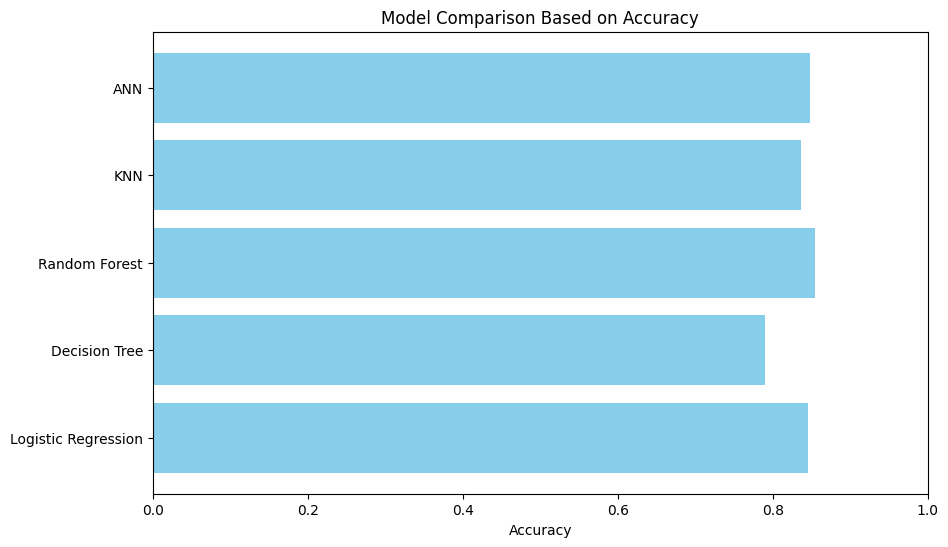

In [37]:
import matplotlib.pyplot as plt

# Model names and their corresponding accuracies
models = ['Logistic Regression',  'Decision Tree',
          'Random Forest',  'KNN', 'ANN']
accuracies = [ 0.8455641900207461,
              0.7902879848095925, 0.8541087942614016,
               0.8368789338584338, 0.8481662505713984]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(models, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Comparison Based on Accuracy')
plt.xlim(0, 1)  # Accuracy ranges from 0 to 1

# Display the plot
plt.show()


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define a function to evaluate each model
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n{model_name} Evaluation Metrics:")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



# Evaluate each model

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_ann, "ANN")



Logistic Regression Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27623
           1       1.00      1.00      1.00      7926

    accuracy                           1.00     35549
   macro avg       1.00      1.00      1.00     35549
weighted avg       1.00      1.00      1.00     35549


Confusion Matrix:
[[27623     0]
 [   38  7888]]

Decision Tree Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27623
           1       1.00      1.00      1.00      7926

    accuracy                           1.00     35549
   macro avg       1.00      1.00      1.00     35549
weighted avg       1.00      1.00      1.00     35549


Confusion Matrix:
[[27623     0]
 [    0  7926]]

Random Forest Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

        

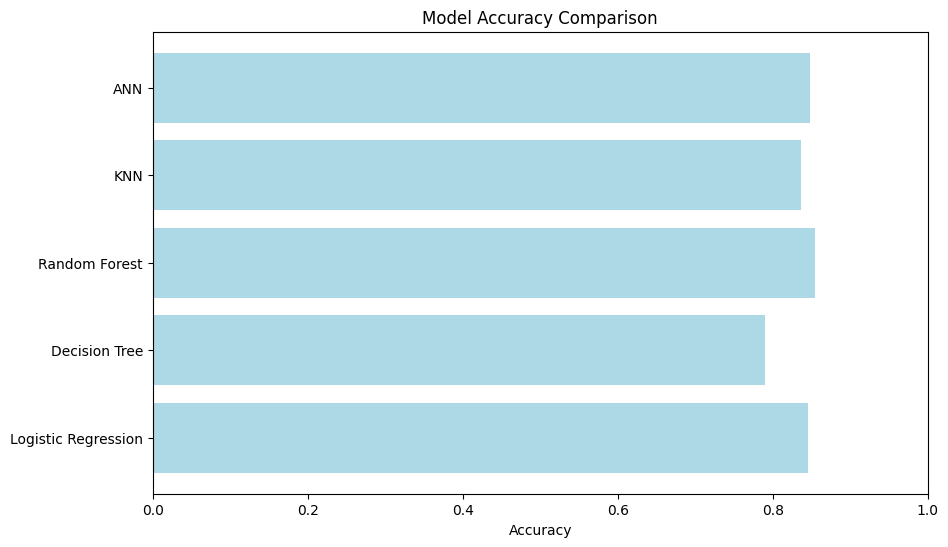

In [39]:
# Accuracy Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(models, accuracies, color='lightblue')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()

In [40]:
# Confusion Matrix Heatmap Function
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

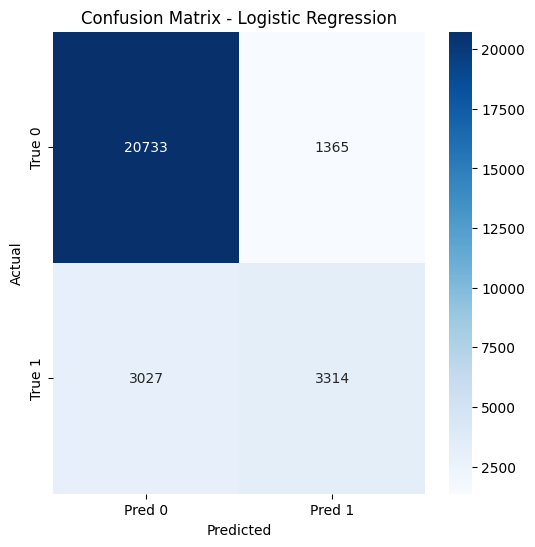

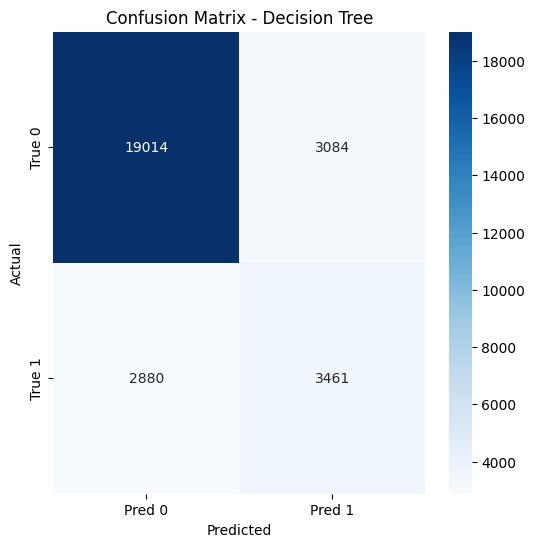

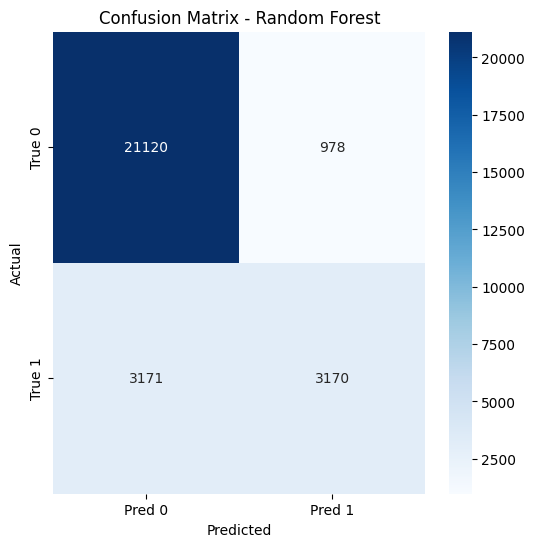

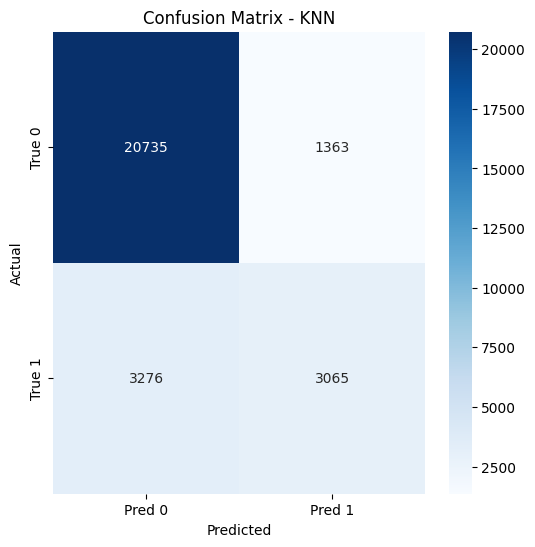

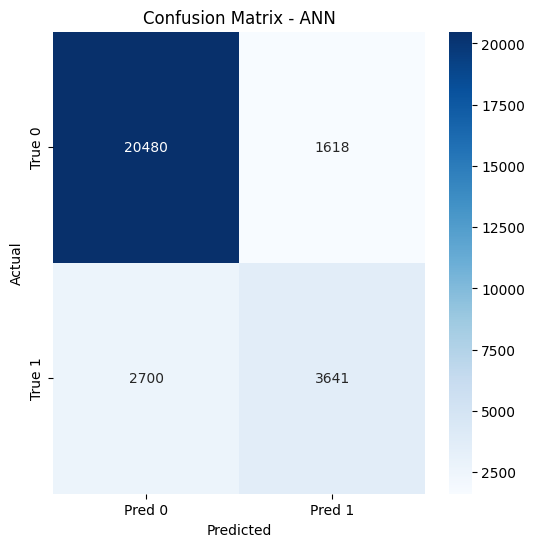

In [41]:
# Confusion Matrices for Each Model
conf_matrices = {

    'Logistic Regression': np.array([[20733, 1365], [3027, 3314]]),
    'Decision Tree': np.array([[19014, 3084], [2880, 3461]]),
    'Random Forest': np.array([[21120, 978], [3171, 3170]]),
    'KNN': np.array([[20735, 1363], [3276, 3065]]),
    'ANN': np.array([[20480, 1618], [2700, 3641]])
}

# Plot confusion matrices for each model
for model_name, cm in conf_matrices.items():
    plot_confusion_matrix(cm, model_name)

In [43]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Sample dataset (replace with your dataset)
# X: Features, y: Target
# X, y = load_your_data()  # Replace with actual data loading code
# For illustration, we'll use sklearn's dataset
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=35549, n_features=10, n_informative=8, n_classes=2, class_sep=2, weights=[0.78, 0.22], random_state=42)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(max_iter=1000)
}

# Initialize a dictionary to store results
results = {}

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Get classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        "accuracy": accuracy,
        "precision_class_0": report['0']['precision'],
        "recall_class_0": report['0']['recall'],
        "f1_class_0": report['0']['f1-score'],
        "precision_class_1": report['1']['precision'],
        "recall_class_1": report['1']['recall'],
        "f1_class_1": report['1']['f1-score'],
        "confusion_matrix": cm
    }

# Convert results into a DataFrame for easy comparison
results_df = pd.DataFrame(results).T

# Display results
print("Model Comparison Results:")
print(results_df)



Model Comparison Results:
                     accuracy precision_class_0 recall_class_0 f1_class_0  \
Logistic Regression  0.931177          0.933318       0.980626   0.956387   
Decision Tree        0.969433          0.978739       0.981601   0.980168   
Random Forest        0.987623          0.986856       0.997198      0.992   
KNN                  0.990436          0.991272       0.996345   0.993802   
ANN                  0.992124          0.991886       0.997929   0.994898   

                    precision_class_1 recall_class_1 f1_class_1  \
Logistic Regression          0.922135        0.76607   0.836889   
Decision Tree                0.937962       0.928804   0.933361   
Random Forest                0.990304       0.955655   0.972671   
KNN                          0.987583       0.970708   0.979073   
ANN                           0.99294       0.972742   0.982737   

                               confusion_matrix  
Logistic Regression  [[8048, 159], [575, 1883]]  
Decision